<div dir="rtl">

# طبقه‌بندی خودکار محصولات برای گروه اوتو

## مرور پروژه
این پروژه بر روی طبقه‌بندی خودکار محصولات برای گروه اوتو (Otto Group)، یکی از غول‌های بزرگ تجارت الکترونیک جهان، متمرکز است.

## بیان مسئله
به دلیل تنوع زیرساخت‌های اطلاعاتی در بیش از ۲۰ کشور:
- محصولات کاملاً یکسان اغلب در سیستم‌های مختلف با برچسب‌های متفاوتی ثبت می‌شوند.
- این ناهماهنگی، دقت تحلیل‌های عملکردی و گزارش‌های فروش را به شدت کاهش می‌دهد.

## هدف پروژه
هدف اصلی، ساخت یک مدل پیش‌بینی‌کننده بر پایه یادگیری ماشین با استفاده از:
- ۲۰۰,۰۰۰ محصول
- ۹۳ ویژگی

این مدل باید بتواند دسته‌بندی اصلی هر کالا را با دقت بالا تشخیص دهد تا کیفیت تحلیل سبد کالا در سطح جهانی یکپارچه و بهبود یابد.

---
نکته: مدل نهایی به صورت متن‌باز (Open Source) ارائه خواهد شد.

</div>

#### Life cycle of Project

- 1) Understanding the Problem Statement
- 2) Data Collection
- 3) Data Checks to perform
- 4) Exploratory data analysis
- 5) Data Pre-Processing
- 6) Feature selection
- 7) Model Training
- 8) Choose best model

### 1) Problem Statement: 
 Due to inconsistent classification of identical products across Otto Group's diverse global infrastructure, 
 this project aims to build a predictive model using 200,000+ products with 93 features to accurately distinguish main product categories and enable reliable performance analysis.

 ### 2) Data Collection
 - Dataset Source : https://www.kaggle.com/c/otto-group-product-classification-challenge
 - The Data Consists of 93 columns & 200,000 rows .

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import optuna


#### Import the CSV Data as Pandas DataFrame

In [4]:
df = pd.read_csv("otto-group-product-classification-challenge/train.csv")
df.head()

,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22,feat_23,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,feat_33,feat_34,feat_35,feat_36,feat_37,feat_38,feat_39,...,feat_55,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64,feat_65,feat_66,feat_67,feat_68,feat_69,feat_70,feat_71,feat_72,feat_73,feat_74,feat_75,feat_76,feat_77,feat_78,feat_79,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,target
0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0,0,0,0,1,0,4,1,1,0,0,2,0,0,0,0,0,1,0,0,0,0,...,0,0,2,0,0,11,0,1,1,0,1,0,7,0,0,0,1,0,0,0,0,0,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,Class_1
1,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,2,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Class_1
2,3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,6,0,0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,Class_1
3,4,1,0,0,1,6,1,5,0,0,1,1,0,1,0,0,1,1,0,0,0,0,0,0,7,2,2,0,0,0,58,0,10,0,0,0,0,0,3,0,...,1,0,0,0,0,0,0,0,0,0,2,1,5,0,0,4,0,0,2,1,0,1,0,0,1,1,2,2,0,22,0,1,2,0,0,0,0,0,0,Class_1
4,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,3,0,0,0,0,0,0,0,4,0,1,0,0,0,1,0,0,0,0,1,0,0,0,Class_1


In [5]:
df.shape

(61878, 95)

In [6]:
df.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['id', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6',
       'feat_7', 'feat_8', 'feat_9', 'feat_10', 'feat_11', 'feat_12',
       'feat_13', 'feat_14', 'feat_15', 'feat_16', 'feat_17', 'feat_18',
       'feat_19', 'feat_20', 'feat_21', 'feat_22', 'feat_23', 'feat_24',
       'feat_25', 'feat_26', 'feat_27', 'feat_28', 'feat_29', 'feat_30',
       'feat_31', 'feat_32', 'feat_33', 'feat_34', 'feat_35', 'feat_36',
       'feat_37', 'feat_38', 'feat_39', 'feat_40', 'feat_41', 'feat_42',
       'feat_43', 'feat_44', 'feat_45', 'feat_46', 'feat_47', 'feat_48',
       'feat_49', 'feat_50', 'feat_51', 'feat_52', 'feat_53', 'feat_54',
       'feat_55', 'feat_56', 'feat_57', 'feat_58', 'feat_59', 'feat_60',
       'feat_61', 'feat_62', 'feat_63', 'feat_64', 'feat_65', 'feat_66',
       'feat_67', 'feat_68', 'feat_69', 'feat_70', 'feat_71', 'feat_72',
       'feat_73', 'feat_74', 'feat_75', 'feat_76', 'feat_77', 'feat_78',
       'feat_79'

### 2.2 Dataset information 
In this project, a dataset of 200,000 products with 93 features (anonymized and numerical) is provided.

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check various categories present in the different categorical column
- Check statistics of data set
- check outlier 
- check scaling
- check imbalance 

### 3.1 Check Missing values


In [7]:
df.isnull().sum().sum()

np.int64(0)

#### There are no mising values in the data set

### 3.2 Check Duplicated


In [8]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3 Check Datatypes

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61878 entries, 0 to 61877
Data columns (total 95 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       61878 non-null  int64 
 1   feat_1   61878 non-null  int64 
 2   feat_2   61878 non-null  int64 
 3   feat_3   61878 non-null  int64 
 4   feat_4   61878 non-null  int64 
 5   feat_5   61878 non-null  int64 
 6   feat_6   61878 non-null  int64 
 7   feat_7   61878 non-null  int64 
 8   feat_8   61878 non-null  int64 
 9   feat_9   61878 non-null  int64 
 10  feat_10  61878 non-null  int64 
 11  feat_11  61878 non-null  int64 
 12  feat_12  61878 non-null  int64 
 13  feat_13  61878 non-null  int64 
 14  feat_14  61878 non-null  int64 
 15  feat_15  61878 non-null  int64 
 16  feat_16  61878 non-null  int64 
 17  feat_17  61878 non-null  int64 
 18  feat_18  61878 non-null  int64 
 19  feat_19  61878 non-null  int64 
 20  feat_20  61878 non-null  int64 
 21  feat_21  61878 non-null  int64 
 22

In [10]:
df.dtypes.value_counts()

int64     94
object     1
Name: count, dtype: int64

### 3.4 Checking the number of unique values of each column

In [11]:
df.nunique()

id         61878
feat_1        42
feat_2        37
feat_3        48
feat_4        59
           ...  
feat_90       91
feat_91       50
feat_92       19
feat_93       43
target         9
Length: 95, dtype: int64

### 3.5 Check statistics of data set

In [12]:
df.describe()

,id,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22,feat_23,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,feat_33,feat_34,feat_35,feat_36,feat_37,feat_38,feat_39,...,feat_54,feat_55,feat_56,feat_57,feat_58,feat_59,feat_60,feat_61,feat_62,feat_63,feat_64,feat_65,feat_66,feat_67,feat_68,feat_69,feat_70,feat_71,feat_72,feat_73,feat_74,feat_75,feat_76,feat_77,feat_78,feat_79,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93
count,61878.000000,61878.00000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,...,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000,61878.000000
mean,30939.500000,0.38668,0.263066,0.901467,0.779081,0.071043,0.025696,0.193704,0.662433,1.011296,0.263906,1.252869,0.140874,0.480979,1.696693,1.284398,1.413459,0.366108,0.575423,0.551699,0.471525,0.204014,0.729969,0.142522,2.643880,1.534520,0.563108,0.696613,0.238970,0.275768,0.150312,0.148680,1.043796,0.696516,0.946411,0.666263,0.709089,0.263632,0.582129,0.485585,...,2.072465,0.323120,0.303775,0.309108,0.697970,0.388603,1.029930,0.239746,1.187563,0.168590,1.256796,0.222228,0.571706,2.897653,0.392902,0.811128,0.892789,0.319290,0.858722,0.591050,0.579851,0.726817,0.748457,0.124196,0.366415,0.300446,0.698067,0.078461,0.187983,0.496719,0.070752,0.532306,1.128576,0.393549,0.874915,0.457772,0.812421,0.264941,0.380119,0.126135
std,17862.784315,1.52533,1.252073,2.934818,2.788005,0.438902,0.215333,1.030102,2.255770,3.474822,1.083340,3.042333,0.567089,2.014697,3.163212,3.862236,2.226163,1.477436,1.335985,4.636145,1.438727,0.696050,1.446220,0.782979,4.629015,2.332994,1.710305,2.873222,0.828112,1.901294,1.640880,0.897354,2.416849,1.310202,3.368622,3.197965,2.555119,0.756934,1.602579,3.298315,...,4.113319,0.998743,1.925806,1.082148,3.983722,2.577693,3.028469,1.017553,2.666742,0.946158,3.402080,0.783052,1.361874,4.974322,1.761054,4.111091,1.941368,1.162443,2.411646,5.783233,3.757822,3.200095,2.920038,0.906621,2.778317,1.285569,2.245671,0.461244,0.836269,2.434921,1.151460,1.900438,2.681554,1.575455,2.115466,1.527385,4.597804,2.045646,0.982385,1.201720
min,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15470.250000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000

#### Preparing X and Y variables

In [ ]:
target_col = "target"
y = df[target_col]
X = df.drop(columns=[target_col, "id"])

In [21]:
zero_stats = pd.DataFrame({
    "zero_count": (X == 0).sum(),
    "zero_pct": (X == 0).mean() * 100,
    "mean": X.mean(),
    "std": X.std(),
    "max": X.max()
})

zero_stats = zero_stats.sort_values(
    "zero_pct",
    ascending=False
)

zero_stats

,zero_count,zero_pct,mean,std,max
feat_6,60710,98.112415,0.025696,0.215333,10
feat_84,60455,97.700314,0.070752,1.151460,76
feat_51,60159,97.221953,0.053298,0.513820,44
feat_5,58907,95.198617,0.071043,0.438902,19
feat_81,58695,94.856007,0.078461,0.461244,26
...,...,...,...,...,...
feat_16,31649,51.147419,1.413459,2.226163,37
feat_48,28174,45.531530,1.584893,2.577071,49
feat_25,27295,44.110993,1.534520,2.332994,30
feat_67,23930,38.672872,2.897653,4.974322,104


#### Insight
a large proportion of the numerical features are zero-inflated

### 4. Exploring Data ( Visualization )


In [ ]:
y.nunique()

In [ ]:
classes = sorted(y.unique())
print(classes)

In [ ]:
y.value_counts().sort_values()


target
Class_1     1929
Class_4     2691
Class_5     2739
Class_7     2839
Class_9     4955
Class_3     8004
Class_8     8464
Class_6    14135
Class_2    16122
Name: count, dtype: int64

In [ ]:
y.value_counts(normalize=True).mul(100).round(2)

target
Class_2    26.05
Class_6    22.84
Class_8    13.68
Class_3    12.94
Class_9     8.01
Class_7     4.59
Class_5     4.43
Class_4     4.35
Class_1     3.12
Name: proportion, dtype: float64

In [ ]:
y.describe()

count       61878
unique          9
top       Class_2
freq        16122
Name: target, dtype: object

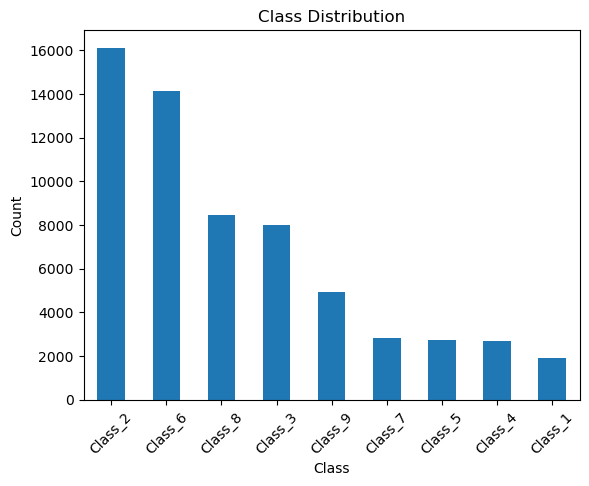

In [ ]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

### Dimention reduction

#### 1. variance & correlation filtering

In [30]:
variance_stats = X.var().sort_values()

print(variance_stats)


feat_6      0.046369
feat_5      0.192635
feat_81     0.212746
feat_51     0.264011
feat_12     0.321590
             ...    
feat_90    21.139806
feat_24    21.427777
feat_19    21.493836
feat_67    24.743876
feat_73    33.445780
Length: 93, dtype: float64


In [31]:
variance_stats.describe()

count    93.000000
mean      5.723553
std       6.202494
min       0.046369
25%       1.351274
50%       3.614918
75%       7.772970
max      33.445780
dtype: float64

In [28]:
for threshold in [0, 0.001, 0.01, 0.1, 1]:
    
    count = (variance_stats <= threshold).sum()
    
    print(f"Variance <= {threshold}: {count} features")

Variance <= 0: 0 features
Variance <= 0.001: 0 features
Variance <= 0.01: 0 features
Variance <= 0.1: 1 features
Variance <= 1: 16 features


##### Variance filtering were removed because the features showed no zero-variance or highly correlated variables, making these steps unnecessary.

In [33]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

max_corr = upper.max().max()

print("Maximum absolute correlation:", max_corr)

Maximum absolute correlation: 0.8241457123086415


#### The maximum absolute correlation was only 0.824, below the 0.90 threshold, so no highly redundant feature pairs were identified

### split data to train & valid set

In [34]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_valid.shape)
print(y_valid.shape)



(49502, 93)
(12376, 93)
(12376,)


### Building model

#### 1. baseline = LogisticRegression & randomforest

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_linear = scaler.fit_transform(X_train)
X_valid_linear = scaler.transform(X_valid)

In [62]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=1.0,
    random_state=42
)

logreg.fit(X_train_linear, y_train)

y_pred_lr = logreg.predict(X_valid_linear)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_valid, y_pred_lr))
print("Balanced Accuracy:", balanced_accuracy_score(y_valid, y_pred_lr))
print("Macro F1:", f1_score(y_valid, y_pred_lr, average="macro"))
print("Weighted F1:", f1_score(y_valid, y_pred_lr, average="weighted"))
print("macro precision:", precision_score(y_valid, y_pred_lr, average="macro", zero_division=0))
print("macro_recall:", recall_score(y_valid,y_pred_lr, average="macro",zero_division=0))


print("\nClassification Report:")
print(classification_report(y_valid, y_pred_lr))

===== Logistic Regression =====
Accuracy: 0.7177601809954751
Balanced Accuracy: 0.7364552466811879
Macro F1: 0.6869329588270945
Weighted F1: 0.731699233147185
macro precision: 0.671789136825091
macro_recall: 0.7364552466811879

Classification Report:
              precision    recall  f1-score   support

     Class_1       0.34      0.70      0.46       386
     Class_2       0.77      0.59      0.67      3224
     Class_3       0.50      0.52      0.51      1601
     Class_4       0.32      0.65      0.43       538
     Class_5       0.90      0.98      0.94       548
     Class_6       0.97      0.85      0.90      2827
     Class_7       0.54      0.72      0.62       568
     Class_8       0.91      0.84      0.87      1693
     Class_9       0.81      0.78      0.79       991

    accuracy                           0.72     12376
   macro avg       0.67      0.74      0.69     12376
weighted avg       0.76      0.72      0.73     12376



In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_selector = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train, y_train)
y_pred_rf_selector = rf_selector.predict(X_valid)



In [ ]:


models = {
    "Logistic Regression": (logreg, X_valid_linear),
    "Random Forest": (rf_selector, X_valid)
    
}

results = []

for name, (model, X_val) in models.items():

    y_pred = model.predict(X_val)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_valid, y_pred),
        "Macro F1": f1_score(
            y_valid, y_pred,
            average="macro"
        ),
        "Weighted F1": f1_score(
            y_valid, y_pred,
            average="weighted"
        ),
        "Macro Precision": precision_score(
            y_valid, y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_valid, y_pred,
            average="macro",
            zero_division=0
        )
    })





print(results)
results_df = pd.DataFrame(results)
results_df


[{'Model': 'Logistic Regression', 'Accuracy': 0.7177601809954751, 'Balanced Accuracy': 0.7364552466811879, 'Macro F1': 0.6869329588270945, 'Weighted F1': 0.731699233147185, 'Macro Precision': 0.671789136825091, 'Macro Recall': 0.7364552466811879}, {'Model': 'Random Forest', 'Accuracy': 0.8081771170006464, 'Balanced Accuracy': 0.7320923187381678, 'Macro F1': 0.7608809715999943, 'Weighted F1': 0.7985095765472681, 'Macro Precision': 0.8218023112503137, 'Macro Recall': 0.7320923187381678}]


,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0,Logistic Regression,0.717760,0.736455,0.686933,0.731699,0.671789,0.736455
1,Random Forest,0.808177,0.732092,0.760881,0.798510,0.821802,0.732092


<div dir='rtl'>

در مجموع، Random Forest به‌عنوان Baseline قوی‌تر انتخاب می‌شود، زیرا در Accuracy، Macro F1، Weighted F1 و Macro Precision عملکرد بهتری دارد. اگرچه Logistic Regression در Balanced Accuracy کمی بهتر عمل کرده است، اما Macro F1 پایین‌تر آن نشان می‌دهد که عملکرد متعادل آن در میان کلاس‌ها ضعیف‌تر است. 

<div>

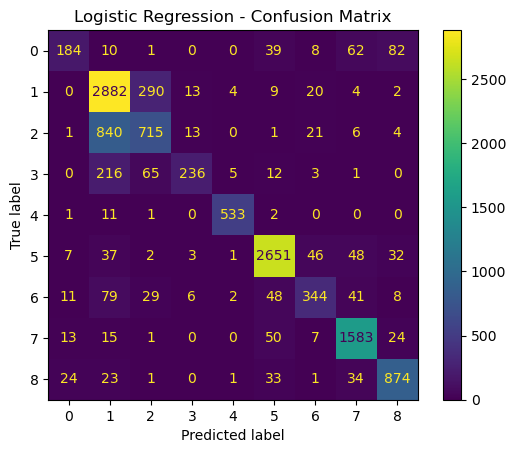

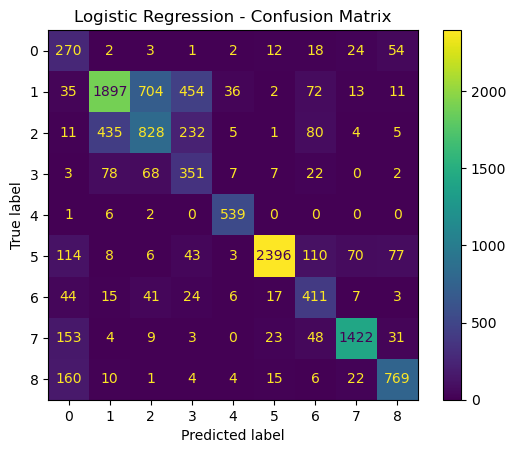

In [77]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_rf_selector = confusion_matrix(y_valid, y_pred_rf_selector)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_selector)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

cm =confusion_matrix(y_valid, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()



<div dir='rtl'>
مشکل مشترک هر دو مدل، تفکیک کلاس‌های 1 و 2 است.

این می‌تواند نشان دهد که Featureهای فعلی برای جدا کردن این دو کلاس اطلاعات کافی ندارند یا این دو کلاس از نظر Feature Space بسیار شبیه هستند.

اما Random Forest در مقایسه با Logistic Regression توانسته بسیاری از اشتباهات را در کلاس‌های دیگر کاهش دهد و در نتیجه Macro F1 بالاتری به دست آورده است.
<div>

In [114]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_valid_xgb = label_encoder.transform(y_valid)


### Feature Selection

In [125]:

feature_counts = [50, 70, 93]



selection_models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        random_seed=42,
        verbose=False
    )
}



results = []

selected_features_dict = {}

for model_name, selector_model in selection_models.items():

    print("\n" + "=" * 60)
    print(f"Feature Selection for: {model_name}")
    print("=" * 60)

   

    if model_name == "XGBoost":

        selector_model.fit(
            X_train,
            y_train_xgb
        )

    else:

        selector_model.fit(
            X_train,
            y_train
        )

    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": selector_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    ).reset_index(drop=True)

    print(
        f"Total features: {len(importance_df)}"
    )


    for n_features in feature_counts:

        # Top-N
        selected_features = (
            importance_df
            .head(n_features)["feature"]
            .tolist()
        )

        X_train_selected = X_train[
            selected_features
        ]

        X_valid_selected = X_valid[
            selected_features
        ]



        if model_name == "Random Forest":

            model = RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )

            model.fit(
                X_train_selected,
                y_train
            )


        elif model_name == "XGBoost":

            model = XGBClassifier(
                n_estimators=300,
                random_state=42,
                eval_metric="mlogloss",
                n_jobs=-1
            )

            model.fit(
                X_train_selected,
                y_train_xgb
            )


        elif model_name == "CatBoost":

            model = CatBoostClassifier(
                iterations=300,
                random_seed=42,
                verbose=False
            )

            model.fit(
                X_train_selected,
                y_train
            )



        y_pred = model.predict(
            X_valid_selected
        )

        y_pred = np.asarray(
            y_pred
        ).ravel()



     

        if model_name == "XGBoost":
              y_pred = label_encoder.inverse_transform(y_pred.astype(int))

        results.append({

            "Model": model_name,

            "n_features": n_features,

            "Accuracy": accuracy_score(
                y_valid,
                y_pred
            ),

            "Balanced Accuracy": balanced_accuracy_score(
                y_valid,
                y_pred
            ),

            "Macro F1": f1_score(
                y_valid,
                y_pred,
                average="macro",
                zero_division=0
            ),

            "Weighted F1": f1_score(
                y_valid,
                y_pred,
                average="weighted",
                zero_division=0
            ),

            "Macro Precision": precision_score(
                y_valid,
                y_pred,
                average="macro",
                zero_division=0
            ),

            "Macro Recall": recall_score(
                y_valid,
                y_pred,
                average="macro",
                zero_division=0
            )
        })



    selected_features_dict[model_name] = importance_df




results_df = pd.DataFrame(results)

results_df


Feature Selection for: Random Forest
Total features: 93

Feature Selection for: XGBoost
Total features: 93

Feature Selection for: CatBoost
Total features: 93


,Model,n_features,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0,Random Forest,50,0.804945,0.727620,0.753661,0.795361,0.809206,0.727620
1,Random Forest,70,0.810197,0.732382,0.760677,0.799894,0.822336,0.732382
2,Random Forest,93,0.808743,0.729753,0.759052,0.798233,0.823455,0.729753
3,XGBoost,50,0.812702,0.759155,0.773438,0.808321,0.794412,0.759155
4,XGBoost,70,0.823449,0.772474,0.789206,0.819883,0.813320,0.772474
5,XGBoost,93,0.824580,0.771385,0.788598,0.821013,0.814844,0.771385
6,CatBoost,50,0.796865,0.726315,0.745643,0.789836,0.781630,0.726315
7,CatBoost,70,0.804056,0.737140,0.757551,0.797566,0.794849,0.737140
8,CatBoost,93,0.806480,0.741334,0.761984,0.799723,0.798984,0.741334


In [126]:
best_results = (
    results_df
    .sort_values(
        ["Model", "Macro F1"],
        ascending=[True, False]
    )
    .groupby("Model")
    .head(1)
    .reset_index(drop=True)
)

best_results

,Model,n_features,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0,CatBoost,93,0.806480,0.741334,0.761984,0.799723,0.798984,0.741334
1,Random Forest,70,0.810197,0.732382,0.760677,0.799894,0.822336,0.732382
2,XGBoost,70,0.823449,0.772474,0.789206,0.819883,0.813320,0.772474


In [127]:
results_df[
    [
        "Model",
        "n_features",
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1"
    ]
].sort_values(
    ["Model", "n_features"]
)

,Model,n_features,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
6,CatBoost,50,0.796865,0.726315,0.745643,0.789836
7,CatBoost,70,0.804056,0.737140,0.757551,0.797566
8,CatBoost,93,0.806480,0.741334,0.761984,0.799723
0,Random Forest,50,0.804945,0.727620,0.753661,0.795361
1,Random Forest,70,0.810197,0.732382,0.760677,0.799894
2,Random Forest,93,0.808743,0.729753,0.759052,0.798233
3,XGBoost,50,0.812702,0.759155,0.773438,0.808321
4,XGBoost,70,0.823449,0.772474,0.789206,0.819883
5,XGBoost,93,0.824580,0.771385,0.788598,0.821013


In [128]:
results_df.pivot(
    index="n_features",
    columns="Model",
    values="Macro F1"
)

Model,CatBoost,Random Forest,XGBoost
n_features,,,
50,0.745643,0.753661,0.773438
70,0.757551,0.760677,0.789206
93,0.761984,0.759052,0.788598


In [129]:
best_n = (
    best_results
    .set_index("Model")["n_features"]
    .to_dict()
)

print(best_n)

{'CatBoost': 93, 'Random Forest': 70, 'XGBoost': 70}


In [137]:


final_features = {}

for model_name, n in best_n.items():

    final_features[model_name] = (
        selected_features_dict[model_name]
        .head(int(n))["feature"]
        .tolist()
    )


rf_features = final_features["Random Forest"]
xgb_features = final_features["XGBoost"]
cb_features = final_features["CatBoost"]

In [138]:
X_train_rf = X_train[rf_features]
X_valid_rf = X_valid[rf_features]

X_train_xgb = X_train[xgb_features]
X_valid_xgb = X_valid[xgb_features]

X_train_cb = X_train[cb_features]
X_valid_cb = X_valid[cb_features]

<div dir="rtl">

 ### گزارش خلاصه Feature Selection و مقایسه مدل‌ها

در این مرحله، برای تعیین تعداد بهینه ویژگی‌ها، تعداد مختلفی از ویژگی‌های برتر شامل 50، 70 و 93 ویژگی برای هر مدل بررسی شد. Feature Selection به‌صورت اختصاصی برای هر مدل و بر اساس Feature Importance انجام گرفت و عملکرد مدل‌ها با معیارهایی مانند Accuracy، Balanced Accuracy، Macro F1 و Weighted F1 مقایسه شد.

<div>

<div dir="rtl">


نتایج نشان داد که کاهش ویژگی برای همه مدل‌ها به یک اندازه مناسب نیست. بهترین تعداد ویژگی برای Random Forest و XGBoost برابر 70 ویژگی و برای CatBoost برابر 93 ویژگی به دست آمد.

<div>

<div dir="rtl">
با توجه به نامتوازن بودن کلاس‌ها، Macro F1 و Balanced Accuracy معیارهای مهم‌تری برای مقایسه در نظر گرفته شدند. بر اساس این معیارها، XGBoost با 70 ویژگی بهترین عملکرد کلی را نشان داد. 

بنابراین در مرحله بعد، این مجموعه ویژگی‌ها به Hyperparameter Tuning با Optuna وارد می‌شوند تا بهترین پارامترهای  مدل تعیین شده و سپس بهترین مدل روی داده‌های نهایی آموزش داده شود.
<div>

In [ ]:
import optuna

from sklearn.metrics import f1_score

In [ ]:
from xgboost import XGBClassifier


def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 200, 600, step=100
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        "random_state": 42,

        "eval_metric": "mlogloss",

        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_xgb,
        y_train_xgb
    )

    y_pred = model.predict(
        X_valid_xgb
    )

    y_pred = np.asarray(
        y_pred
    ).ravel()

    y_pred = label_encoder.inverse_transform(
        y_pred.astype(int)
    )

    score = f1_score(
        y_valid,
        y_pred,
        average="macro",
        zero_division=0
    )

    return score

In [143]:
study_xgb = optuna.create_study(
    direction="maximize"
)

study_xgb.optimize(
    objective_xgb,
    n_trials=30
)

print("Best XGB Macro F1:", study_xgb.best_value)
print("Best XGB Parameters:")
print(study_xgb.best_params)

[I 2026-08-23 00:02:09,854] A new study created in memory with name: no-name-8479085c-3b4f-42c8-95b2-cef7c9850655
[I 2026-08-23 00:02:28,351] Trial 0 finished with value: 0.7661482389592094 and parameters: {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.03963766797492726, 'subsample': 0.6407665252861177, 'colsample_bytree': 0.6825237678117527, 'min_child_weight': 8, 'gamma': 1.1120704232261103, 'reg_alpha': 0.00020314457683067363, 'reg_lambda': 8.944171499247575e-08}. Best is trial 0 with value: 0.7661482389592094.
[I 2026-08-23 00:02:41,250] Trial 1 finished with value: 0.7580213785770338 and parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.17714513953634226, 'subsample': 0.8407455155459006, 'colsample_bytree': 0.8545222777564128, 'min_child_weight': 3, 'gamma': 3.0365214968345726, 'reg_alpha': 3.087584017183016e-07, 'reg_lambda': 0.0173994200212042}. Best is trial 0 with value: 0.7661482389592094.
[I 2026-08-23 00:03:14,240] Trial 2 finished with value: 0

Best XGB Macro F1: 0.7946666661011839
Best XGB Parameters:
{'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.0962467079172944, 'subsample': 0.807825503863869, 'colsample_bytree': 0.650800559597417, 'min_child_weight': 7, 'gamma': 0.01079847794609018, 'reg_alpha': 1.4145391115126846e-08, 'reg_lambda': 0.23270017827543807}


In [144]:
study_xgb.best_value

0.7946666661011839

In [145]:
study_xgb.best_params

{'n_estimators': 400,
 'max_depth': 10,
 'learning_rate': 0.0962467079172944,
 'subsample': 0.807825503863869,
 'colsample_bytree': 0.650800559597417,
 'min_child_weight': 7,
 'gamma': 0.01079847794609018,
 'reg_alpha': 1.4145391115126846e-08,
 'reg_lambda': 0.23270017827543807}

In [146]:


best_xgb = XGBClassifier(
    **study_xgb.best_params,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

best_xgb.fit(
    X_train_xgb,
    y_train_xgb
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.650800559597417
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [147]:
X_train_xgb

,feat_11,feat_90,feat_60,feat_34,feat_39,feat_69,feat_36,feat_15,feat_68,feat_47,feat_84,feat_75,feat_26,feat_91,feat_14,feat_53,feat_42,feat_59,feat_78,feat_40,feat_50,feat_86,feat_30,feat_9,feat_35,feat_17,feat_77,feat_19,feat_43,feat_62,feat_58,feat_57,feat_7,feat_67,feat_56,feat_23,feat_41,feat_92,feat_2,feat_25,feat_72,feat_45,feat_76,feat_51,feat_88,feat_8,feat_29,feat_93,feat_64,feat_24,feat_79,feat_83,feat_32,feat_85,feat_38,feat_81,feat_1,feat_13,feat_55,feat_16,feat_48,feat_71,feat_20,feat_49,feat_80,feat_27,feat_54,feat_4,feat_37,feat_5
21359,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0,13,0,2,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0
4961,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,4,0,1,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,5,0,0,0,0,5,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0
20087,0,0,0,0,0,0,0,4,0,1,0,0,0,0,2,1,1,0,0,0,0,1,1,6,0,0,0,0,0,2,0,0,0,12,0,0,0,0,1,2,1,0,0,0,3,5,0,0,20,16,0,0,8,0,1,0,0,1,0,2,0,0,1,1,0,0,3,0,1,0
44778,6,0,2,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0,2,5,0,8,10,0,0
39229,6,0,0,0,0,0,0,0,3,3,1,0,8,0,0,0,1,0,0,0,0,0,0,0,2,1,0,0,0,4,0,0,0,1,2,0,1,3,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,3,0,0,0,1,3,9,2,2,1,3,2,1,14,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41818,12,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,2,0,1,0,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,2,1,0,0,0,0,0,0,2,0,0,0,0,11,28,6,6,0,0
52736,1,4,0,0,0,13,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,75,0,0,11,0,0,1,0,0,0,0,0,0,0,1,8,0,0,0,0,0,2,7,0,0,4,0,2,0,0,0,0,1,3,0,1,0,0,0,1,0,0,0
11743,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,13,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,1,0,0,1,0,0,0,0,0,18,2,0,0,6,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0
37702,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,8,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2,11,0,1,0,0,0,0,0,0,1,1,2,0,0,0,5,1,7,11,0,0


In [148]:

y_pred_xgb = best_xgb.predict(X_valid_xgb)

y_pred_xgb = np.asarray(y_pred_xgb).ravel()

y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb.astype(int))

In [ ]:


xgb_results = {

    "Model": "Best XGBoost",

    "n_features": X_train_xgb.shape[1],

    "Accuracy": accuracy_score(
        y_valid,
        y_pred_xgb
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_valid,
        y_pred_xgb
    ),

    "Macro F1": f1_score(
        y_valid,
        y_pred_xgb,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_valid,
        y_pred_xgb,
        average="weighted",
        zero_division=0
    ),

    "Macro Precision": precision_score(
        y_valid,
        y_pred_xgb,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_valid,
        y_pred_xgb,
        average="macro",
        zero_division=0
    )
}

print(xgb_results)

{'Model': 'Best XGBoost', 'n_features': 70, 'Accuracy': 0.8265998707175177, 'Balanced Accuracy': 0.7770023974472181, 'Macro F1': 0.7946666661011839, 'Weighted F1': 0.8232982113958349, 'Macro Precision': 0.8211517996240985, 'Macro Recall': 0.7770023974472181}


In [150]:
xgb_results_df = pd.DataFrame([xgb_results])

xgb_results_df

,Model,n_features,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
0,Best XGBoost,70,0.8266,0.777002,0.794667,0.823298,0.821152,0.777002


In [151]:
from sklearn.metrics import confusion_matrix, classification_report

cm_xgb = confusion_matrix(y_valid, y_pred_xgb)

print(cm_xgb)

[[ 222    6    0    0    1   34   11   43   69]
 [   6 2731  402   32    5   10   28    4    6]
 [   3  633  901   27    0    1   28    4    4]
 [   0  136   83  301    4   11    3    0    0]
 [   0    8    2    1  535    0    1    0    1]
 [   8   21    2    5    0 2672   49   42   28]
 [  11   48   41    5    1   42  397   16    7]
 [  20   10    2    0    0   36   14 1590   21]
 [  27   15    1    0    3   30    2   32  881]]


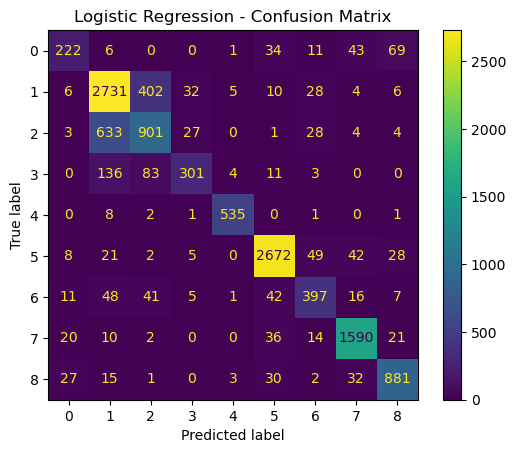

In [155]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

<div dir='rtl'>

جمع‌بندی

در مجموع، Confusion Matrix نشان می‌دهد که XGBoost توانسته مرزبندی کلاس‌ها را نسبت به Logistic Regression بهتر یاد بگیرد، اما همچنان یک هم‌پوشانی قابل توجه بین Class 1 و Class 2 وجود دارد.

<div>

<div dir="rtl'>
جمع‌بندی

در مجموع، Confusion Matrix نشان می‌دهد که XGBoost توانسته مرزبندی کلاس‌ها را نسبت به Logistic Regression بهتر یاد بگیرد، اما همچنان یک هم‌پوشانی قابل توجه بین Class 1 و Class 2 وجود دارد.
<div>

In [152]:
print(classification_report(y_valid, y_pred_xgb, zero_division=0))

              precision    recall  f1-score   support

     Class_1       0.75      0.58      0.65       386
     Class_2       0.76      0.85      0.80      3224
     Class_3       0.63      0.56      0.59      1601
     Class_4       0.81      0.56      0.66       538
     Class_5       0.97      0.98      0.98       548
     Class_6       0.94      0.95      0.94      2827
     Class_7       0.74      0.70      0.72       568
     Class_8       0.92      0.94      0.93      1693
     Class_9       0.87      0.89      0.88       991

    accuracy                           0.83     12376
   macro avg       0.82      0.78      0.79     12376
weighted avg       0.82      0.83      0.82     12376



<div dir="rtl">

گزارش

پس از انجام Feature Selection و انتخاب 70 ویژگی برای XGBoost، مرحله‌ی Hyperparameter Tuning با Optuna انجام شد. نتایج نشان داد که تنظیم پارامترهای مدل باعث بهبود عملکرد در تمام معیارهای اصلی شد.

مهم‌ترین بهبود مربوط به Macro F1 بود که از 0.7892 به 0.7947 افزایش یافت. همچنین Balanced Accuracy از 0.7725 به 0.7770 رسید که نشان‌دهنده‌ی بهبود عملکرد مدل در مواجهه با کلاس‌های مختلف است.

بنابراین در حال حاضر:

Best XGBoost با 70 Feature و Hyperparameters بهینه‌شده، بهترین مدل پروژه در مرحله Validation است.
<div>

<div dir="rtl">
مرحله بعدی بهتر است قبل از رفتن به  test  بار دیگر مدل با داده train و  valid  و همین 70 تا  feature  و  best parametrs  دوباره آموزش دهیم و فقط یکبار روی test set  ارزیابی کنیم
<div>